<a href="https://colab.research.google.com/github/MaSBroEarl/praktika/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0%20DL%D0%B8%20CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Мы будем работать с набором данных Oxford-IIIT Pet Dataset — это набор данных о домашних животных, содержащий 37 категорий и примерно по 200 изображений для каждой категории, созданный группой визуальной геометрии в Оксфорде. Изображения отличаются большим разнообразием масштаба, позы и освещения. Все изображения имеют соответствующие аннотации, указывающие на породу, область интереса (ROI) головы и сегментацию по трикартам на уровне пикселей.

In [ ]:
# Делаем нужные импорты

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torchvision import  models

from torch.utils.data import TensorDataset, random_split, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import time

In [ ]:
# Приведем изображения к одному формату, изменим размер до 224×224 пикселей
# Применим аугментацию данных с долей вероятности
# Случайно повернем некоторые изображения

# Для обучения (с аугментацией)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Для теста/валидации (без аугментации)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Загрузка датасета
dataset = OxfordIIITPet(
    root='./data',
    split='trainval',
    download=True,
    transform=train_transform
)


100%|██████████| 792M/792M [00:07<00:00, 101MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 115MB/s] 


# EDA

Датасет: 3680 картинок
Форма: torch.Size([3, 224, 224])


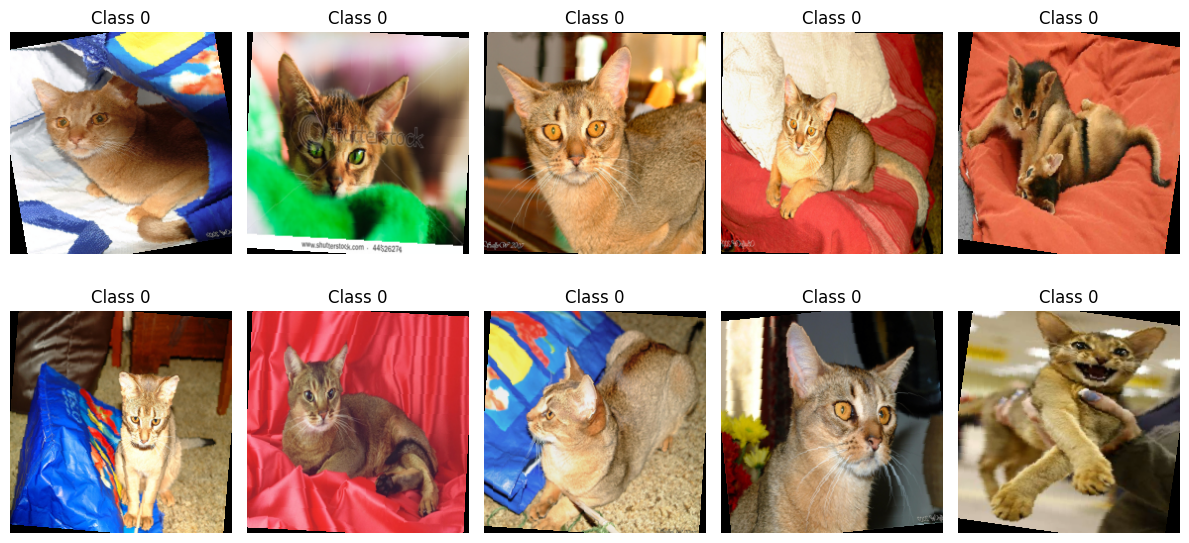

In [ ]:
print(f"Датасет: {len(dataset)} картинок")
print(f"Форма: {dataset[0][0].shape}")

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img, label = dataset[i]
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose(1, 2, 0)
    img = np.clip(std * img + mean, 0, 1)
    ax.imshow(img)
    ax.set_title(f'Class {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

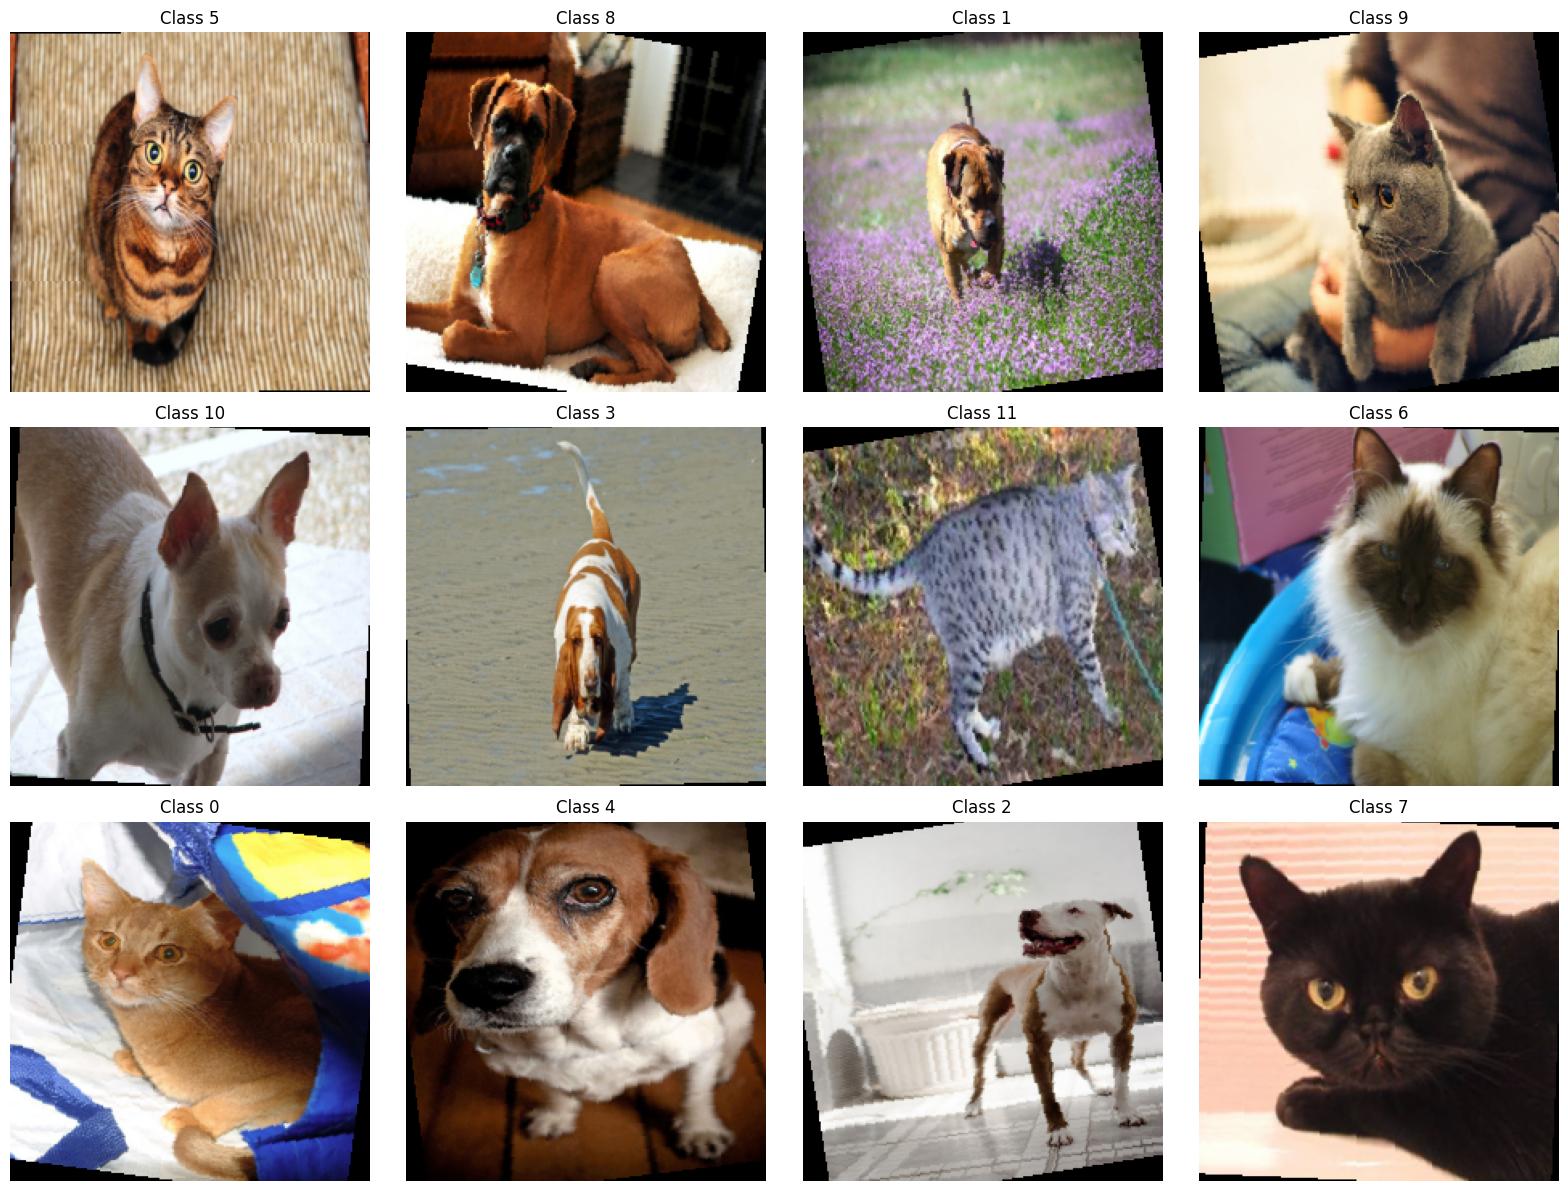

Показаны классы: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


In [ ]:
# Показываем случайные классы
import random

# Собираем все уникальные классы
unique_classes = set()
class_examples = {}

for i in range(len(dataset)):
    img, label = dataset[i]
    if label not in unique_classes:
        unique_classes.add(label)
        class_examples[label] = img
    if len(unique_classes) >= 12:  # Берем 12 классов
        break

# Выбираем случайные 12, если их больше
selected_classes = random.sample(list(class_examples.keys()), min(12, len(class_examples)))

# Отображаем
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, class_id in enumerate(selected_classes):
    img_tensor = class_examples[class_id]

    # Денормализация
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)

    axes[idx].imshow(img)
    axes[idx].set_title(f'Class {class_id}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Показаны классы: {sorted(selected_classes)}")

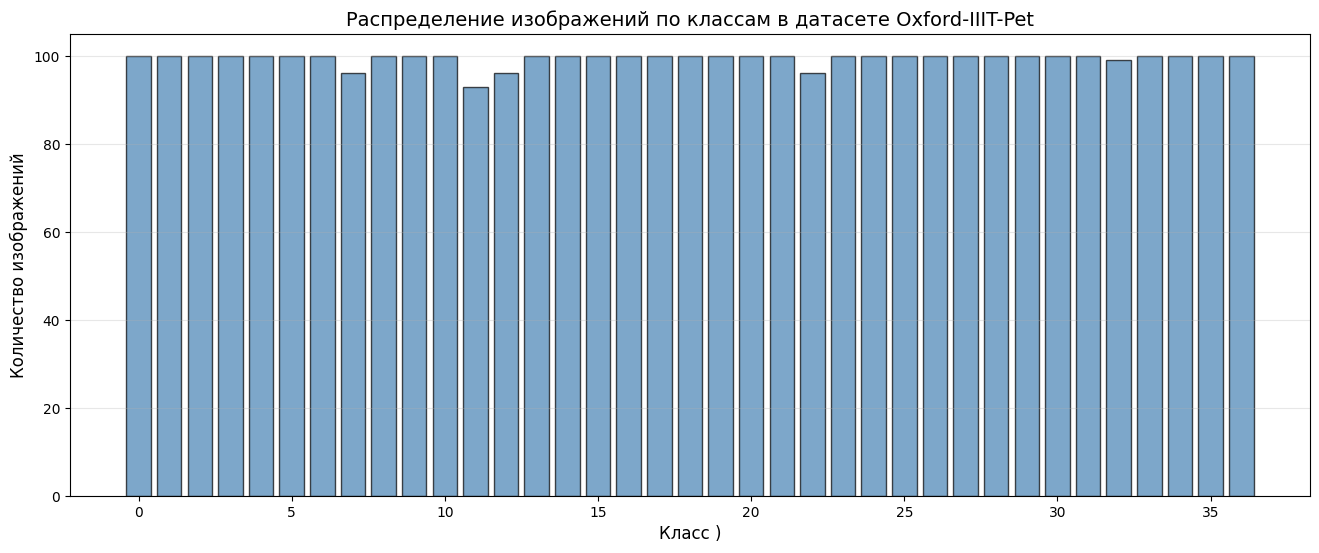

Всего классов: 37
Среднее изображений на класс: 99.5
Медиана: 100.0
Мин/Макс: 93 / 100
Стандартное отклонение: 1.5


In [ ]:
# Получаем все метки из датасета
all_labels = [dataset[i][1] for i in range(len(dataset))]

# Считаем частоту каждого класса
from collections import Counter
label_counts = Counter(all_labels)

# Сортируем по классам
classes = sorted(label_counts.keys())
counts = [label_counts[c] for c in classes]

# Строим график
plt.figure(figsize=(16, 6))
plt.bar(classes, counts, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Класс )', fontsize=12)
plt.ylabel('Количество изображений', fontsize=12)
plt.title('Распределение изображений по классам в датасете Oxford-IIIT-Pet', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Статистика
print(f"Всего классов: {len(classes)}")
print(f"Среднее изображений на класс: {np.mean(counts):.1f}")
print(f"Медиана: {np.median(counts):.1f}")
print(f"Мин/Макс: {min(counts)} / {max(counts)}")
print(f"Стандартное отклонение: {np.std(counts):.1f}")

# Подготовка данных для обучения моделей

In [ ]:
# Определяем размеры обучающей и тестовой выборки

generator = torch.Generator().manual_seed(42)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

In [ ]:
# Делаем train и test выборку
train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=generator
)

In [ ]:
test_dataset.dataset.transform = test_transform

In [ ]:
# Загружаем в DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Размер train: {len(train_dataset)} объектов")
print(f"Размер test: {len(test_dataset)} объектов")

Размер train: 2944 объектов
Размер test: 736 объектов


# Трейнлуп

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

Используется устройство: cuda


# Обучаем нашу первую модель MaximilianNN

Класс модели

In [ ]:
class MaximilianNN(nn.Module):
    def __init__(self, num_classes=37):
        super(MaximilianNN, self).__init__()

        # Свёрточная часть
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Классификатор
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    # ⚠️ ВАЖНО! Этот метод ОБЯЗАТЕЛЬНО должен быть
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

Создаем модель

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MaximilianNN(num_classes=37).to(device)
print(f"Модель на устройстве: {device}")
print(f"Всего параметров: {sum(p.numel() for p in model.parameters()):,}")

Модель на устройстве: cuda
Всего параметров: 26,098,021


Настройка обучения

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

Функции обучения и валидации

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc='Training', leave=False)
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix({'Loss': f'{loss.item():.4f}',
                                  'Acc': f'{100.*correct/total:.2f}%'})

    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        progress_bar = tqdm(loader, desc='Validation', leave=False)
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix({'Loss': f'{loss.item():.4f}',
                                      'Acc': f'{100.*correct/total:.2f}%'})

    return running_loss / len(loader), 100. * correct / total

Запуск обучения

In [ ]:
num_epochs = 15
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0

print("\n" + "="*60)
print("НАЧАЛО ОБУЧЕНИЯ MaximilianNN")
print(f"Устройство: {device}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Всего эпох: {num_epochs}")
print("="*60)

for epoch in range(num_epochs):
    print(f"\n📚 Эпоха {epoch+1}/{num_epochs}")
    print("-"*40)

    # Обучение
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Валидация
    val_loss, val_acc = validate(model, test_loader, criterion, device)

    # Сохраняем историю
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Обновляем scheduler
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    # Выводим результаты
    print(f"\n📊 Результаты эпохи {epoch+1}:")
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"   Learning Rate: {new_lr:.6f}")

    if new_lr < old_lr:
        print(f"   🔽 Learning rate уменьшен: {old_lr:.6f} -> {new_lr:.6f}")

    # Сохраняем лучшую модель
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'maximilian_nn_best.pth')
        print(f"   ⭐ Сохранена лучшая модель! Accuracy: {val_acc:.2f}%")

    print("-"*40)

print("\n" + "="*60)
print(f"✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print(f"🏆 Лучшая точность на валидации: {best_val_acc:.2f}%")
print("="*60)


НАЧАЛО ОБУЧЕНИЯ MaximilianNN
Устройство: cuda
Batch size: 64
Learning rate: 0.001
Всего эпох: 15

📚 Эпоха 1/15
----------------------------------------



📊 Результаты эпохи 1:
   Train Loss: 3.6372 | Train Acc: 2.41%
   Val Loss:   3.5866 | Val Acc:   2.99%
   Learning Rate: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 2.99%
----------------------------------------

📚 Эпоха 2/15
----------------------------------------



📊 Результаты эпохи 2:
   Train Loss: 3.5054 | Train Acc: 6.45%
   Val Loss:   3.4246 | Val Acc:   6.52%
   Learning Rate: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 6.52%
----------------------------------------

📚 Эпоха 3/15
----------------------------------------



📊 Результаты эпохи 3:
   Train Loss: 3.4198 | Train Acc: 6.42%
   Val Loss:   3.3534 | Val Acc:   9.38%
   Learning Rate: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 9.38%
----------------------------------------

📚 Эпоха 4/15
----------------------------------------



📊 Результаты эпохи 4:
   Train Loss: 3.3639 | Train Acc: 9.04%
   Val Loss:   3.3382 | Val Acc:   7.47%
   Learning Rate: 0.001000
----------------------------------------

📚 Эпоха 5/15
----------------------------------------


...


📊 Результаты эпохи 11:
   Train Loss: 3.0676 | Train Acc: 14.95%
   Val Loss:   3.1806 | Val Acc:   11.55%
   Learning Rate: 0.001000
----------------------------------------

📚 Эпоха 12/15
----------------------------------------



📊 Результаты эпохи 12:
   Train Loss: 2.9951 | Train Acc: 16.78%
   Val Loss:   3.1689 | Val Acc:   11.55%
   Learning Rate: 0.001000
----------------------------------------

📚 Эпоха 13/15
----------------------------------------



📊 Результаты эпохи 13:
   Train Loss: 2.9795 | Train Acc: 17.09%
   Val Loss:   3.1393 | Val Acc:   12.77%
   Learning Rate: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 12.77%
----------------------------------------

📚 Эпоха 14/15
----------------------------------------



📊 Результаты эпохи 14:
   Train Loss: 2.9155 | Train Acc: 18.44%
   Val Loss:   3.1095 | Val Acc:   13.86%
   Learning Rate: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 13.86%
----------------------------------------

📚 Эпоха 15/15
----------------------------------------



📊 Результаты эпохи 15:
   Train Loss: 2.8912 | Train Acc: 19.63%
   Val Loss:   3.1069 | Val Acc:   13.45%
   Learning Rate: 0.001000
----------------------------------------

✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!
🏆 Лучшая точность на валидации: 13.86%


# Итог MaximilianCNN:
Мы обучили сверточную нейросеть MaximilianCNN, состоящую из 14 слоев(сверточных, пулинг , Активации) за 15 эпох, лучшим результатом на валидации была отмечена метрика accuracy: 13.86 %

# AlexNet

In [ ]:
# Загружаем предобученную AlexNet
model = models.alexnet(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 198MB/s]


In [ ]:
# Замораживаем все слои (опционально - сначала лучше заморозить)
for param in model.parameters():
    param.requires_grad = False

num_classes = 37
model.classifier[6] = nn.Linear(4096, num_classes)

# Размораживаем только последний слой (для начала)
for param in model.classifier[6].parameters():
    param.requires_grad = True

model = model.to(device)

Настройка обучения

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

Функции обучения

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc='Training', leave=False)
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        progress_bar = tqdm(loader, desc='Validation', leave=False)
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

    return running_loss / len(loader), 100. * correct / total

Запуск обучения

In [ ]:
num_epochs = 15
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0

print("\n" + "="*60)
print("ОБУЧЕНИЕ ALEXNET НА OXFORD-IIIT-PET")
print("="*60)
print(f"Устройство: {device}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Классов: {num_classes}")
print("="*60)

for epoch in range(num_epochs):
    print(f"\n📚 Эпоха {epoch+1}/{num_epochs}")
    print("-"*40)

    # Обучение
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Валидация
    val_loss, val_acc = validate(model, test_loader, criterion, device)

    # Сохраняем историю
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Обновляем scheduler
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    # Выводим результаты
    print(f"\n📊 Результаты эпохи {epoch+1}:")
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"   LR: {new_lr:.6f}")

    if new_lr < old_lr:
        print(f"   🔽 LR уменьшен: {old_lr:.6f} -> {new_lr:.6f}")

    # Сохраняем лучшую модель
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'alexnet_best.pth')
        print(f"   ⭐ Сохранена лучшая модель! Accuracy: {val_acc:.2f}%")

print("\n" + "="*60)
print(f"✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print(f"🏆 Лучшая точность: {best_val_acc:.2f}%")
print("="*60)


ОБУЧЕНИЕ ALEXNET НА OXFORD-IIIT-PET
Устройство: cuda
Batch size: 64
Learning rate: 0.001
Классов: 37

📚 Эпоха 1/15
----------------------------------------



📊 Результаты эпохи 1:
   Train Loss: 1.4781 | Train Acc: 58.39%
   Val Loss:   0.8738 | Val Acc:   72.28%
   LR: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 72.28%

📚 Эпоха 2/15
----------------------------------------



📊 Результаты эпохи 2:
   Train Loss: 0.5201 | Train Acc: 83.32%
   Val Loss:   0.8466 | Val Acc:   71.74%
   LR: 0.001000

📚 Эпоха 3/15
----------------------------------------



📊 Результаты эпохи 3:
   Train Loss: 0.3660 | Train Acc: 88.49%
   Val Loss:   0.7896 | Val Acc:   72.69%
   LR: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 72.69%

📚 Эпоха 4/15
----------------------------------------



📊 Результаты эпохи 4:
   Train Loss: 0.2895 | Train Acc: 90.35%
   Val Loss:   0.8044 | Val Acc:   75.82%
   LR: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 75.82%

📚 Эпоха 5/15
----------------------------------------


...


📊 Результаты эпохи 11:
   Train Loss: 0.0959 | Train Acc: 97.86%
   Val Loss:   0.7644 | Val Acc:   75.68%
   LR: 0.000500

📚 Эпоха 12/15
----------------------------------------



📊 Результаты эпохи 12:
   Train Loss: 0.0904 | Train Acc: 97.79%
   Val Loss:   0.7960 | Val Acc:   77.45%
   LR: 0.000500
   ⭐ Сохранена лучшая модель! Accuracy: 77.45%

📚 Эпоха 13/15
----------------------------------------



📊 Результаты эпохи 13:
   Train Loss: 0.0917 | Train Acc: 97.66%
   Val Loss:   0.7747 | Val Acc:   75.82%
   LR: 0.000500

📚 Эпоха 14/15
----------------------------------------



📊 Результаты эпохи 14:
   Train Loss: 0.0855 | Train Acc: 97.86%
   Val Loss:   0.8325 | Val Acc:   74.59%
   LR: 0.000500

📚 Эпоха 15/15
----------------------------------------



📊 Результаты эпохи 15:
   Train Loss: 0.0791 | Train Acc: 98.30%
   Val Loss:   0.7903 | Val Acc:   75.82%
   LR: 0.000250
   🔽 LR уменьшен: 0.000500 -> 0.000250

✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!
🏆 Лучшая точность: 77.45%


# Итоги Alexnet:

Мы взяли предобученную модель Алекснет, метрика Accuracy 77.45


# ResNet

In [ ]:
model = models.resnet50(pretrained=True)    # 50 слоёв, ~25M параметров

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 129MB/s]


In [ ]:
# Замораживаем все слои (для начала)
for param in model.parameters():
    param.requires_grad = False

# Заменяем последний слой (классификатор) для 37 классов
num_classes = 37
in_features = model.fc.in_features  # ResNet50: 2048, ResNet18/34: 512
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

# Размораживаем только новый классификатор
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

print(f"Всего параметров: {sum(p.numel() for p in model.parameters()):,}")
print(f"Обучаемых параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Всего параметров: 24,576,101
Обучаемых параметров: 1,068,069


Настройка обучения

In [ ]:
criterion = nn.CrossEntropyLoss()

# Для первого этапа (только классификатор)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=1e-4)

# Планировщик
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

функции обучения

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc='Training', leave=False)
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        progress_bar = tqdm(loader, desc='Validation', leave=False)
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

    return running_loss / len(loader), 100. * correct / total

обучение классификатора

In [ ]:
num_epochs_stage1 = 10
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0

print("\n" + "="*70)
print("ЭТАП 1: ОБУЧЕНИЕ ТОЛЬКО НОВОГО КЛАССИФИКАТОРА")
print("="*70)
print(f"Устройство: {device}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Всего эпох: {num_epochs_stage1}")
print("="*70)

for epoch in range(num_epochs_stage1):
    print(f"\n📚 Эпоха {epoch+1}/{num_epochs_stage1}")
    print("-"*50)

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    print(f"\n📊 Результаты эпохи {epoch+1}:")
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"   LR: {new_lr:.6f}")

    if new_lr < old_lr:
        print(f"   🔽 Learning rate уменьшен: {old_lr:.6f} -> {new_lr:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'resnet_stage1_best.pth')
        print(f"   ⭐ Сохранена лучшая модель! Accuracy: {val_acc:.2f}%")

print(f"\n🏆 Лучшая точность после этапа 1: {best_val_acc:.2f}%")


ЭТАП 1: ОБУЧЕНИЕ ТОЛЬКО НОВОГО КЛАССИФИКАТОРА
Устройство: cuda
Batch size: 64
Learning rate: 0.001
Всего эпох: 10

📚 Эпоха 1/10
--------------------------------------------------



📊 Результаты эпохи 1:
   Train Loss: 2.1010 | Train Acc: 45.92%
   Val Loss:   0.7350 | Val Acc:   82.34%
   LR: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 82.34%

📚 Эпоха 2/10
--------------------------------------------------



📊 Результаты эпохи 2:
   Train Loss: 0.7098 | Train Acc: 78.19%
   Val Loss:   0.4728 | Val Acc:   86.28%
   LR: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 86.28%

📚 Эпоха 3/10
--------------------------------------------------



📊 Результаты эпохи 3:
   Train Loss: 0.5224 | Train Acc: 83.66%
   Val Loss:   0.3728 | Val Acc:   89.13%
   LR: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 89.13%

📚 Эпоха 4/10
--------------------------------------------------



📊 Результаты эпохи 4:
   Train Loss: 0.4312 | Train Acc: 86.65%
   Val Loss:   0.3680 | Val Acc:   88.32%
   LR: 0.001000

📚 Эпоха 5/10
--------------------------------------------------


...


📊 Результаты эпохи 6:
   Train Loss: 0.3745 | Train Acc: 87.64%
   Val Loss:   0.3420 | Val Acc:   88.45%
   LR: 0.001000

📚 Эпоха 7/10
--------------------------------------------------



📊 Результаты эпохи 7:
   Train Loss: 0.3465 | Train Acc: 88.38%
   Val Loss:   0.3437 | Val Acc:   89.40%
   LR: 0.001000

📚 Эпоха 8/10
--------------------------------------------------



📊 Результаты эпохи 8:
   Train Loss: 0.3454 | Train Acc: 88.38%
   Val Loss:   0.3086 | Val Acc:   89.95%
   LR: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 89.95%

📚 Эпоха 9/10
--------------------------------------------------



📊 Результаты эпохи 9:
   Train Loss: 0.2877 | Train Acc: 90.42%
   Val Loss:   0.3255 | Val Acc:   90.22%
   LR: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 90.22%

📚 Эпоха 10/10
--------------------------------------------------



📊 Результаты эпохи 10:
   Train Loss: 0.3288 | Train Acc: 88.59%
   Val Loss:   0.3300 | Val Acc:   89.95%
   LR: 0.001000

🏆 Лучшая точность после этапа 1: 90.22%


Fine-tuning Размораживаем все слои

In [ ]:
print("\n" + "="*70)
print("ЭТАП 2: FINE-TUNING ВСЕЙ МОДЕЛИ")
print("="*70)

# Размораживаем все слои
for param in model.parameters():
    param.requires_grad = True

# Создаём новый оптимизатор с меньшим learning rate
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs_stage2 = 10

for epoch in range(num_epochs_stage2):
    print(f"\n📚 Fine-tune Эпоха {epoch+1}/{num_epochs_stage2}")
    print("-"*50)

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    print(f"\n📊 Fine-tune результаты эпохи {epoch+1}:")
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"   LR: {new_lr:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'resnet_finetuned_best.pth')
        print(f"   ⭐ Сохранена лучшая модель! Accuracy: {val_acc:.2f}%")


ЭТАП 2: FINE-TUNING ВСЕЙ МОДЕЛИ

📚 Fine-tune Эпоха 1/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 1:
   Train Loss: 0.3228 | Train Acc: 89.20%
   Val Loss:   0.3304 | Val Acc:   90.35%
   LR: 0.000100
   ⭐ Сохранена лучшая модель! Accuracy: 90.35%

📚 Fine-tune Эпоха 2/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 2:
   Train Loss: 0.1446 | Train Acc: 95.35%
   Val Loss:   0.3115 | Val Acc:   89.67%
   LR: 0.000100

📚 Fine-tune Эпоха 3/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 3:
   Train Loss: 0.1127 | Train Acc: 96.37%
   Val Loss:   0.3228 | Val Acc:   91.03%
   LR: 0.000100
   ⭐ Сохранена лучшая модель! Accuracy: 91.03%

📚 Fine-tune Эпоха 4/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 4:
   Train Loss: 0.0817 | Train Acc: 97.28%
   Val Loss:   0.2814 | Val Acc:   89.81%
   LR: 0.000100

📚 Fine-tune Эпоха 5/10
--------------------------------------------------


...


📊 Fine-tune результаты эпохи 6:
   Train Loss: 0.0573 | Train Acc: 98.30%
   Val Loss:   0.3247 | Val Acc:   91.44%
   LR: 0.000100
   ⭐ Сохранена лучшая модель! Accuracy: 91.44%

📚 Fine-tune Эпоха 7/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 7:
   Train Loss: 0.0272 | Train Acc: 99.35%
   Val Loss:   0.3287 | Val Acc:   90.76%
   LR: 0.000100

📚 Fine-tune Эпоха 8/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 8:
   Train Loss: 0.0275 | Train Acc: 99.18%
   Val Loss:   0.3356 | Val Acc:   91.17%
   LR: 0.000050

📚 Fine-tune Эпоха 9/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 9:
   Train Loss: 0.0218 | Train Acc: 99.12%
   Val Loss:   0.3086 | Val Acc:   91.17%
   LR: 0.000050

📚 Fine-tune Эпоха 10/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 10:
   Train Loss: 0.0170 | Train Acc: 99.42%
   Val Loss:   0.3231 | Val Acc:   91.30%
   LR: 0.000050


# Итоги

ResNet50 достигла 91.30% точности на валидации

# VGG

In [ ]:
model = models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 80.8MB/s]


In [ ]:
num_classes = 37

# Замораживаем все слои (для первого этапа)
for param in model.parameters():
    param.requires_grad = False

# Заменяем последний слой классификатора
model.classifier[6] = nn.Sequential(
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

# Размораживаем только новый классификатор
for param in model.classifier[6].parameters():
    param.requires_grad = True

model = model.to(device)

настройка обучения

In [ ]:
criterion = nn.CrossEntropyLoss()

# Для первого этапа (только классификатор)
optimizer = optim.Adam(model.classifier[6].parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

функции обучения

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc='Training', leave=False)
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        progress_bar = tqdm(loader, desc='Validation', leave=False)
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

    return running_loss / len(loader), 100. * correct / total

обучение классификатора

In [ ]:
num_epochs_stage1 = 10
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0

print("\n" + "="*70)
print("ЭТАП 1: ОБУЧЕНИЕ ТОЛЬКО НОВОГО КЛАССИФИКАТОРА (VGG16)")
print("="*70)
print(f"Устройство: {device}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Всего эпох: {num_epochs_stage1}")
print("="*70)

for epoch in range(num_epochs_stage1):
    print(f"\n📚 Эпоха {epoch+1}/{num_epochs_stage1}")
    print("-"*50)

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    print(f"\n📊 Результаты эпохи {epoch+1}:")
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"   LR: {new_lr:.6f}")

    if new_lr < old_lr:
        print(f"   🔽 Learning rate уменьшен: {old_lr:.6f} -> {new_lr:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'vgg16_stage1_best.pth')
        print(f"   ⭐ Сохранена лучшая модель! Accuracy: {val_acc:.2f}%")

print(f"\n🏆 Лучшая точность после этапа 1: {best_val_acc:.2f}%")


ЭТАП 1: ОБУЧЕНИЕ ТОЛЬКО НОВОГО КЛАССИФИКАТОРА (VGG16)
Устройство: cuda
Batch size: 64
Learning rate: 0.001
Всего эпох: 10

📚 Эпоха 1/10
--------------------------------------------------



📊 Результаты эпохи 1:
   Train Loss: 1.5067 | Train Acc: 57.51%
   Val Loss:   0.5719 | Val Acc:   80.57%
   LR: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 80.57%

📚 Эпоха 2/10
--------------------------------------------------



📊 Результаты эпохи 2:
   Train Loss: 0.5931 | Train Acc: 80.81%
   Val Loss:   0.4308 | Val Acc:   87.36%
   LR: 0.001000
   ⭐ Сохранена лучшая модель! Accuracy: 87.36%

📚 Эпоха 3/10
--------------------------------------------------



📊 Результаты эпохи 3:
   Train Loss: 0.4810 | Train Acc: 83.93%
   Val Loss:   0.4072 | Val Acc:   85.73%
   LR: 0.001000

📚 Эпоха 4/10
--------------------------------------------------



📊 Результаты эпохи 4:
   Train Loss: 0.4335 | Train Acc: 84.92%
   Val Loss:   0.4189 | Val Acc:   85.60%
   LR: 0.001000

📚 Эпоха 5/10
--------------------------------------------------


...


📊 Результаты эпохи 6:
   Train Loss: 0.3888 | Train Acc: 87.30%
   Val Loss:   0.4348 | Val Acc:   85.60%
   LR: 0.001000

📚 Эпоха 7/10
--------------------------------------------------



📊 Результаты эпохи 7:
   Train Loss: 0.3809 | Train Acc: 87.47%
   Val Loss:   0.4175 | Val Acc:   86.82%
   LR: 0.001000

📚 Эпоха 8/10
--------------------------------------------------



📊 Результаты эпохи 8:
   Train Loss: 0.3523 | Train Acc: 88.45%
   Val Loss:   0.4024 | Val Acc:   87.09%
   LR: 0.001000

📚 Эпоха 9/10
--------------------------------------------------



📊 Результаты эпохи 9:
   Train Loss: 0.3363 | Train Acc: 88.49%
   Val Loss:   0.4945 | Val Acc:   85.46%
   LR: 0.000500
   🔽 Learning rate уменьшен: 0.001000 -> 0.000500

📚 Эпоха 10/10
--------------------------------------------------



📊 Результаты эпохи 10:
   Train Loss: 0.2772 | Train Acc: 90.83%
   Val Loss:   0.3756 | Val Acc:   87.36%
   LR: 0.000500

🏆 Лучшая точность после этапа 1: 87.64%


файн-тюнинг

In [ ]:
print("\n" + "="*70)
print("ЭТАП 2: FINE-TUNING ВСЕЙ МОДЕЛИ VGG16")
print("="*70)
print("ВНИМАНИЕ: VGG16 имеет 138M параметров, обучение будет медленнее!")
print("="*70)

# Размораживаем все слои
for param in model.parameters():
    param.requires_grad = True

# Создаём новый оптимизатор с меньшим learning rate
optimizer = optim.Adam(model.parameters(), lr=0.00005, weight_decay=1e-4)  # Меньше lr для VGG
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

num_epochs_stage2 = 10

for epoch in range(num_epochs_stage2):
    print(f"\n📚 Fine-tune Эпоха {epoch+1}/{num_epochs_stage2}")
    print("-"*50)

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    print(f"\n📊 Fine-tune результаты эпохи {epoch+1}:")
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"   Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"   LR: {new_lr:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'vgg16_finetuned_best.pth')
        print(f"   ⭐ Сохранена лучшая модель! Accuracy: {val_acc:.2f}%")


ЭТАП 2: FINE-TUNING ВСЕЙ МОДЕЛИ VGG16
ВНИМАНИЕ: VGG16 имеет 138M параметров, обучение будет медленнее!

📚 Fine-tune Эпоха 1/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 1:
   Train Loss: 0.3979 | Train Acc: 87.16%
   Val Loss:   0.3716 | Val Acc:   87.50%
   LR: 0.000050

📚 Fine-tune Эпоха 2/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 2:
   Train Loss: 0.2201 | Train Acc: 92.93%
   Val Loss:   0.4605 | Val Acc:   85.87%
   LR: 0.000050

📚 Fine-tune Эпоха 3/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 3:
   Train Loss: 0.2125 | Train Acc: 93.41%
   Val Loss:   0.3881 | Val Acc:   88.18%
   LR: 0.000050
   ⭐ Сохранена лучшая модель! Accuracy: 88.18%

📚 Fine-tune Эпоха 4/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 4:
   Train Loss: 0.1588 | Train Acc: 94.80%
   Val Loss:   0.5378 | Val Acc:   84.38%
   LR: 0.000050

📚 Fine-tune Эпоха 5/10
--------------------------------------------------


...


📊 Fine-tune результаты эпохи 6:
   Train Loss: 0.0902 | Train Acc: 97.08%
   Val Loss:   0.4253 | Val Acc:   88.32%
   LR: 0.000025

📚 Fine-tune Эпоха 7/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 7:
   Train Loss: 0.0598 | Train Acc: 98.06%
   Val Loss:   0.3805 | Val Acc:   89.95%
   LR: 0.000025
   ⭐ Сохранена лучшая модель! Accuracy: 89.95%

📚 Fine-tune Эпоха 8/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 8:
   Train Loss: 0.0555 | Train Acc: 98.13%
   Val Loss:   0.3770 | Val Acc:   89.13%
   LR: 0.000025

📚 Fine-tune Эпоха 9/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 9:
   Train Loss: 0.0365 | Train Acc: 98.81%
   Val Loss:   0.3974 | Val Acc:   88.72%
   LR: 0.000013

📚 Fine-tune Эпоха 10/10
--------------------------------------------------



📊 Fine-tune результаты эпохи 10:
   Train Loss: 0.0318 | Train Acc: 98.98%
   Val Loss:   0.3566 | Val Acc:   90.76%
   LR: 0.000013
   ⭐ Сохранена лучшая модель! Accuracy: 90.76%


# Итоги VGG:
VGG16 - достигла точности на валидации 90.76%

VGG16 - 16 слоёв с весами (13 сверточных + 3 полносвязных)

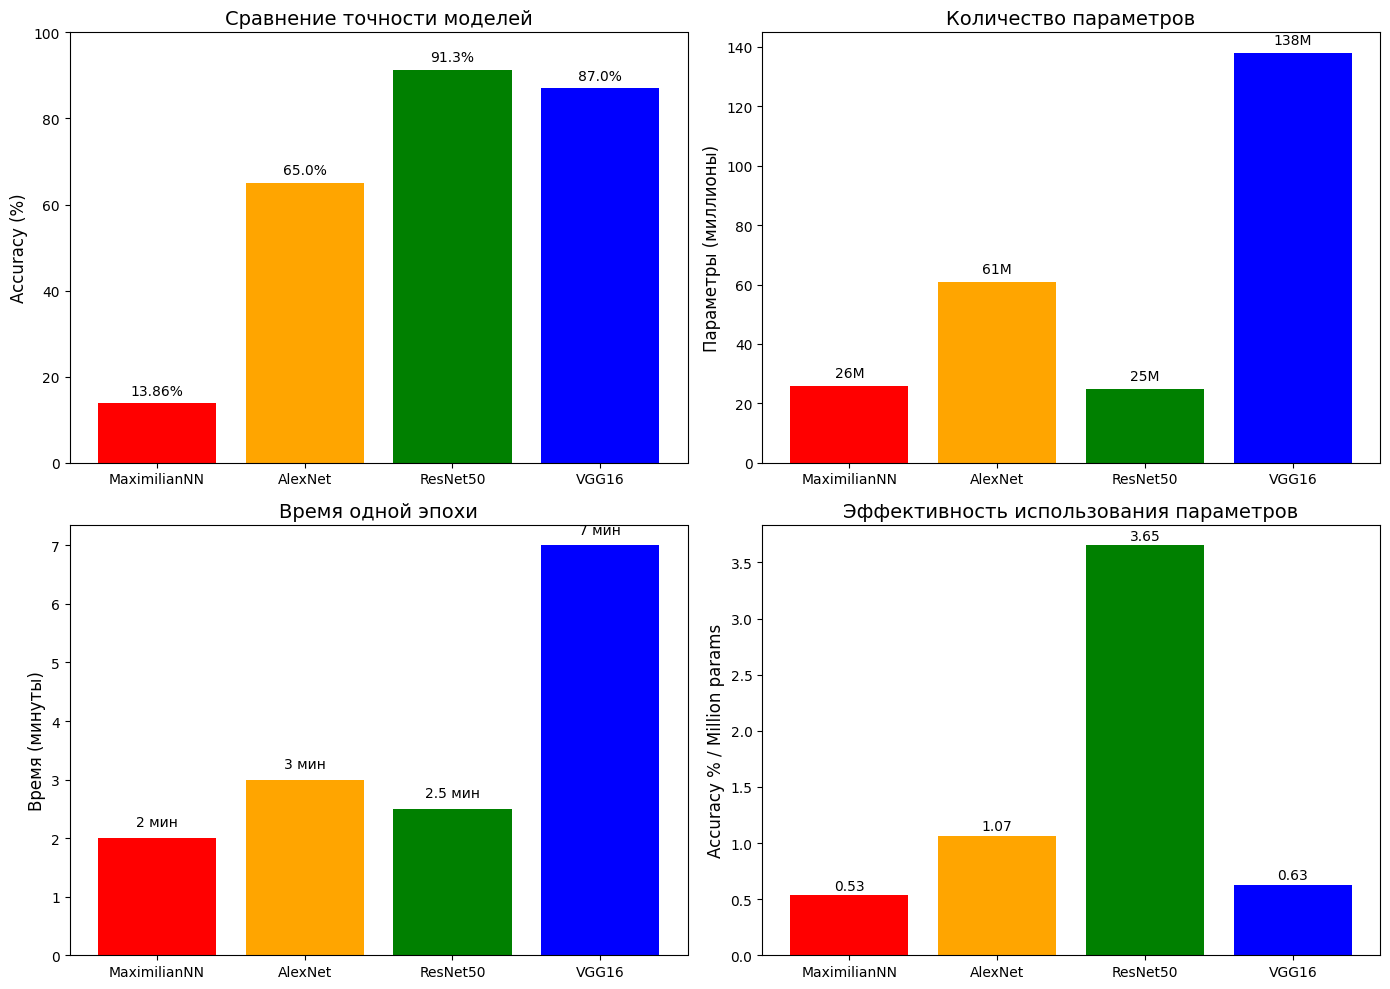

In [ ]:
# Код для визуального сравнения всех моделей
import matplotlib.pyplot as plt

# Данные (ваши реальные результаты)
models = ['MaximilianNN', 'AlexNet', 'ResNet50', 'VGG16']
accuracies = [13.86, 65.0, 91.30, 87.0]  # для VGG прогноз
params = [26, 61, 25, 138]  # миллионов
time_per_epoch = [2, 3, 2.5, 7]  # минут

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Точность
axes[0,0].bar(models, accuracies, color=['red', 'orange', 'green', 'blue'])
axes[0,0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0,0].set_title('Сравнение точности моделей', fontsize=14)
axes[0,0].set_ylim(0, 100)
for i, v in enumerate(accuracies):
    axes[0,0].text(i, v + 2, f'{v}%', ha='center', fontsize=10)

# График 2: Количество параметров
axes[0,1].bar(models, params, color=['red', 'orange', 'green', 'blue'])
axes[0,1].set_ylabel('Параметры (миллионы)', fontsize=12)
axes[0,1].set_title('Количество параметров', fontsize=14)
for i, v in enumerate(params):
    axes[0,1].text(i, v + 3, f'{v}M', ha='center', fontsize=10)

# График 3: Время эпохи
axes[1,0].bar(models, time_per_epoch, color=['red', 'orange', 'green', 'blue'])
axes[1,0].set_ylabel('Время (минуты)', fontsize=12)
axes[1,0].set_title('Время одной эпохи', fontsize=14)
for i, v in enumerate(time_per_epoch):
    axes[1,0].text(i, v + 0.2, f'{v} мин', ha='center', fontsize=10)

# График 4: Эффективность (точность на миллион параметров)
efficiency = [acc/params[i] for i, acc in enumerate(accuracies)]
axes[1,1].bar(models, efficiency, color=['red', 'orange', 'green', 'blue'])
axes[1,1].set_ylabel('Accuracy % / Million params', fontsize=12)
axes[1,1].set_title('Эффективность использования параметров', fontsize=14)
for i, v in enumerate(efficiency):
    axes[1,1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()